In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/student_dropout_dataset_v3.csv')
display(df.head(10))

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
5,6,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,Business,NaN,0
6,7,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0
7,8,22.7,Female,25000.0,Yes,2.12,86.4,1,34.0,No,Yes,6.5,1.79,1.14,1.14,Year 1,Arts,High School,0
8,9,20.0,Male,57413.0,Yes,4.07,97.5,3,52.1,No,No,4.2,3.08,2.81,2.81,Year 1,CS,High School,0
9,10,22.2,Female,44930.0,Yes,2.98,82.2,1,19.7,No,No,6.7,1.59,1.73,1.73,Year 1,Science,Master,0


IF THERE'S ANY DUPLICATE ROW

In [7]:
# Check for duplicate rows in the DataFrame
duplicate_rows = df.duplicated().sum()

if duplicate_rows == 0:
    print("No duplicate rows found in the dataset.")
else:
    print(f"Number of duplicate rows found: {duplicate_rows}")
    # Optionally, display the duplicate rows
    # display(df[df.duplicated(keep=False)])

No duplicate rows found in the dataset.


CALCULATE TARGET COLUM VALUE AND DISPALY GRAPH

,count
Dropout,
0,7646
1,2354


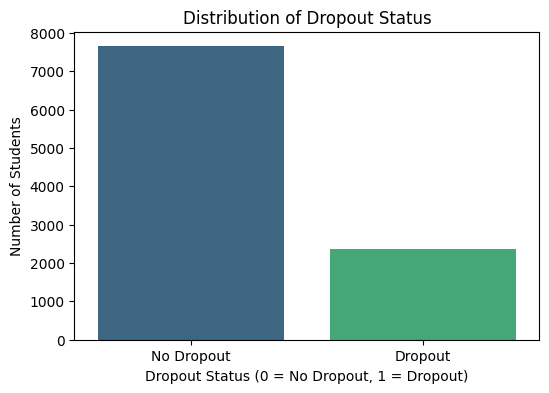

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

target_column = 'Dropout'
y = df[target_column]

# Calculate value counts
dropout_counts = y.value_counts()

# Display the counts
display(dropout_counts)

# Plot the value counts as a bar graph
plt.figure(figsize=(6, 4))
sns.barplot(x=dropout_counts.index, y=dropout_counts.values, hue=dropout_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Dropout Status')
plt.xlabel('Dropout Status (0 = No Dropout, 1 = Dropout)')
plt.ylabel('Number of Students')
plt.xticks(ticks=[0, 1], labels=['No Dropout', 'Dropout'])
plt.show()

CHECKING NULL VALUE

In [9]:
display(df.isnull().sum())

,0
Student_ID,0
Age,0
Gender,0
Family_Income,500
Internet_Access,0
Study_Hours_per_Day,500
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


HANDLE NULL VALUE USING MEAN MEDIAN MODE

In [10]:
# Impute numerical columns with median
df['Family_Income'].fillna(df['Family_Income'].median(), inplace=True)
df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].median(), inplace=True)
df['Stress_Index'].fillna(df['Stress_Index'].median(), inplace=True)

# Impute categorical column with mode
df['Parental_Education'].fillna(df['Parental_Education'].mode()[0], inplace=True)

# Verify that there are no more null values
display(df.isnull().sum())

/tmp/ipykernel_15624/2838133071.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Family_Income'].fillna(df['Family_Income'].median(), inplace=True)
/tmp/ipykernel_15624/2838133071.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

,0
Student_ID,0
Age,0
Gender,0
Family_Income,0
Internet_Access,0
Study_Hours_per_Day,0
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


HANDLE CATEGORICAL VALUE

In [11]:
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    if column != target_column: # Exclude the target column from encoding
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

display(df.head())

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,0,0,1,0
1,2,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,2,3,0,1
2,3,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,0,0,2,0
3,4,24.4,1,29740.5,1,4.00,82.2,2,38.6,0,0,5.5,1.78,1.77,1.77,0,2,1,1
4,5,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,3,1,0,0


CHECK IMBALANCE

In [12]:
print("Data balance for target variable 'Dropout':")
display(y.value_counts())
display(y.value_counts(normalize=True) * 100)

Data balance for target variable 'Dropout':


,count
Dropout,
0,7646
1,2354


,proportion
Dropout,
0,76.46
1,23.54


In [14]:
X = df.drop(columns=[target_column])
y = df[target_column]

APPLY BALANCING

In [15]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Identify categorical columns in X
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# SMOTE apply
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

# Check balance
print("Data balance after SMOTE:")
display(y_resampled.value_counts())
display(y_resampled.value_counts(normalize=True) * 100)

Data balance after SMOTE:


,count
Dropout,
0,7646
1,7646


,proportion
Dropout,
0,50.0
1,50.0


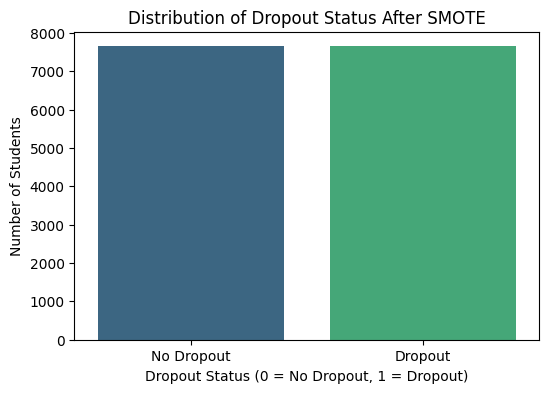

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate value counts for the resampled target variable
dropout_counts_resampled = y_resampled.value_counts()

# Plot the value counts as a bar graph
plt.figure(figsize=(6, 4))
sns.barplot(x=dropout_counts_resampled.index, y=dropout_counts_resampled.values, hue=dropout_counts_resampled.index, palette='viridis', legend=False)
plt.title('Distribution of Dropout Status After SMOTE')
plt.xlabel('Dropout Status (0 = No Dropout, 1 = Dropout)')
plt.ylabel('Number of Students')
plt.xticks(ticks=[0, 1], labels=['No Dropout', 'Dropout'])
plt.show()

SLIPT THE DATA IN (80-20) AND FIT THE MODEL AND RUN RANDOM FOREST

In [17]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Model Accuracy: 0.8137
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81      1565
           1       0.80      0.83      0.81      1494

    accuracy                           0.81      3059
   macro avg       0.81      0.81      0.81      3059
weighted avg       0.81      0.81      0.81      3059



Confusion Matrix for Initial Random Forest Model:
 [[1254  311]
 [ 259 1235]]


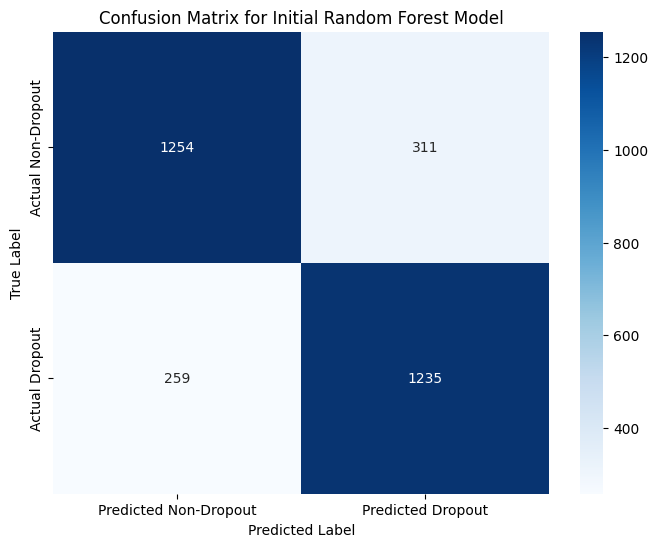

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for the initial Random Forest model
cm_rf = confusion_matrix(y_test, y_pred)

print("Confusion Matrix for Initial Random Forest Model:\n", cm_rf)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Dropout', 'Predicted Dropout'],
            yticklabels=['Actual Non-Dropout', 'Actual Dropout'])
plt.title('Confusion Matrix for Initial Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Predicted Dropout Probabilities

In [19]:
# Get dropout probabilities for the positive class (class 1)
dropout_probabilities = model.predict_proba(X_test_scaled)[:, 1]

# Display the first 10 dropout probabilities as percentages
print("Predicted Dropout Probabilities (Percentage Risk) for the first 10 test samples:")
for i, prob in enumerate(dropout_probabilities[:10]):
    print(f"Sample {i+1}: {prob:.2%}")

# Optionally, add these probabilities to a DataFrame for easier inspection
results_df = pd.DataFrame({
    'Actual_Dropout': y_test.values,
    'Predicted_Class': y_pred,
    'Dropout_Probability': dropout_probabilities
})

print("\nResults DataFrame (first 10 rows):")
display(results_df.head(10))

Predicted Dropout Probabilities (Percentage Risk) for the first 10 test samples:
Sample 1: 86.00%
Sample 2: 64.00%
Sample 3: 75.00%
Sample 4: 67.00%
Sample 5: 81.00%
Sample 6: 11.00%
Sample 7: 79.00%
Sample 8: 21.00%
Sample 9: 14.00%
Sample 10: 15.00%

Results DataFrame (first 10 rows):


,Actual_Dropout,Predicted_Class,Dropout_Probability
0,1,1,0.86
1,0,1,0.64
2,0,1,0.75
3,0,1,0.67
4,1,1,0.81
5,0,0,0.11
6,0,1,0.79
7,0,0,0.21
8,0,0,0.14
9,0,0,0.15


FEATURE IMPORTENCE

In [20]:
# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Get feature names from the preprocessed data (X_resampled)
feature_names = X_resampled.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 15 most important features
print("Top 15 Feature Importances:")
display(importance_df.head(15))

Top 15 Feature Importances:


,Feature,Importance
12,GPA,0.163742
13,Semester_GPA,0.136418
14,CGPA,0.121459
11,Stress_Index,0.081817
6,Attendance_Rate,0.070884
8,Travel_Time_Minutes,0.057970
0,Student_ID,0.056411
5,Study_Hours_per_Day,0.056202
1,Age,0.052661
3,Family_Income,0.038074


FEATURE IMPORTNCE PLOT

/tmp/ipykernel_15624/1313375874.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


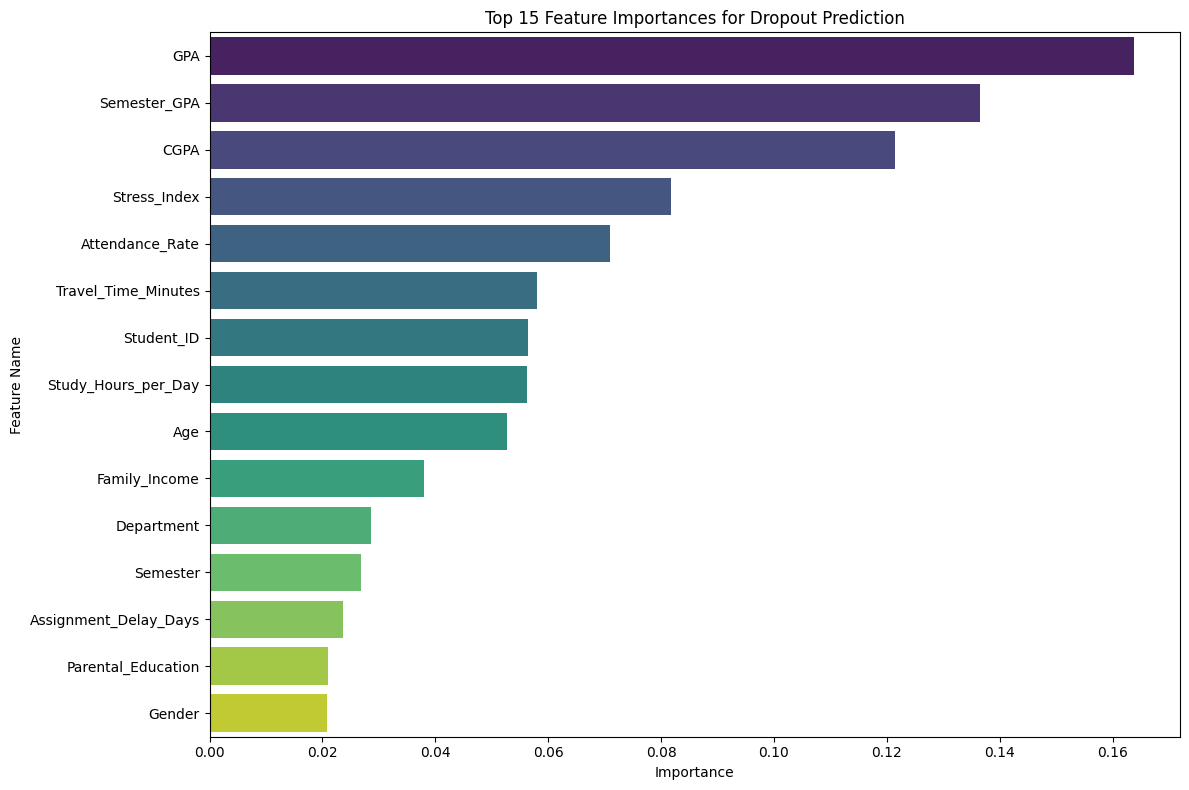

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances for Dropout Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

LOGISTIC REGRESSION MODEL RUN


In [22]:
from sklearn.linear_model import LogisticRegression

# Train a Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets and handles L1/L2 penalties
logistic_model.fit(X_train_scaled, y_train)

# Make predictions with the Logistic Regression model
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Evaluate the Logistic Regression model
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
report_logistic = classification_report(y_test, y_pred_logistic)

print(f"Logistic Regression Model Accuracy: {accuracy_logistic:.4f}")
print("Logistic Regression Classification Report:\n", report_logistic)

Logistic Regression Model Accuracy: 0.7898
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.77      0.79      1565
           1       0.77      0.81      0.79      1494

    accuracy                           0.79      3059
   macro avg       0.79      0.79      0.79      3059
weighted avg       0.79      0.79      0.79      3059



LOGISTIC REGRESSION CONFUSION MATRIX

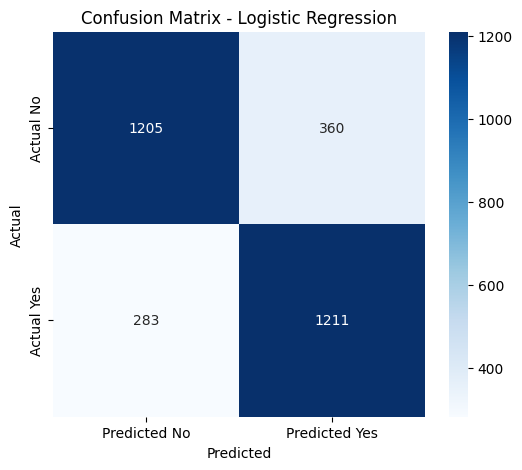

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix calculate
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

FEATURE IMPORTANCE FOR REGRESSION MATRIX

In [ ]:
..............

SVC MODEL RUN

In [24]:
from sklearn.svm import SVC

# Train a Support Vector Classifier model
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions with the SVC model
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate the SVC model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

print(f"SVC Model Accuracy: {accuracy_svm:.4f}")
print("SVC Classification Report:\n", report_svm)

SVC Model Accuracy: 0.8084
SVC Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81      1565
           1       0.79      0.82      0.81      1494

    accuracy                           0.81      3059
   macro avg       0.81      0.81      0.81      3059
weighted avg       0.81      0.81      0.81      3059



CONFUSION MATRIX OF SVC

Confusion Matrix for SVC Model:
 [[1246  319]
 [ 267 1227]]


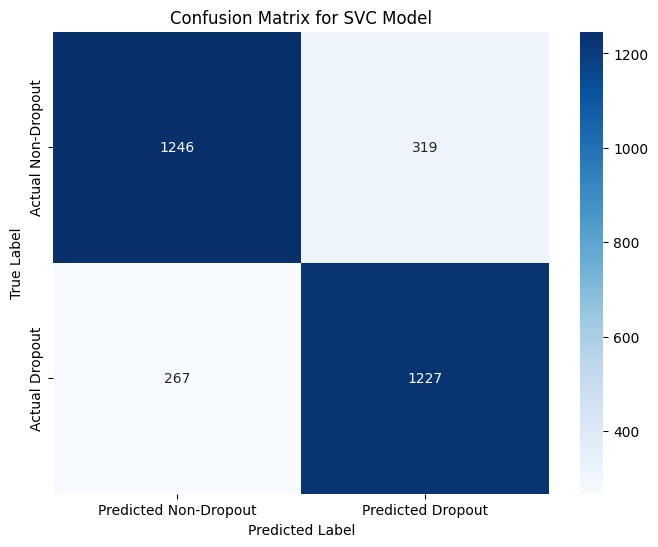

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix for the SVC model
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix for SVC Model:\n", cm_svm)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Dropout', 'Predicted Dropout'],
            yticklabels=['Actual Non-Dropout', 'Actual Dropout'])
plt.title('Confusion Matrix for SVC Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

KNN MODEL RUN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

# Train a K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common starting point
knn_model.fit(X_train_scaled, y_train)

# Make predictions with the KNN model
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate the KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

print(f"K-Nearest Neighbors Model Accuracy: {accuracy_knn:.4f}")
print("K-Nearest Neighbors Classification Report:\n", report_knn)

K-Nearest Neighbors Model Accuracy: 0.7787
K-Nearest Neighbors Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.69      0.76      1565
           1       0.73      0.87      0.79      1494

    accuracy                           0.78      3059
   macro avg       0.79      0.78      0.78      3059
weighted avg       0.79      0.78      0.78      3059



CONFUSION MATRIX OF KNN

Confusion Matrix for K-Nearest Neighbors Model:
 [[1081  484]
 [ 193 1301]]


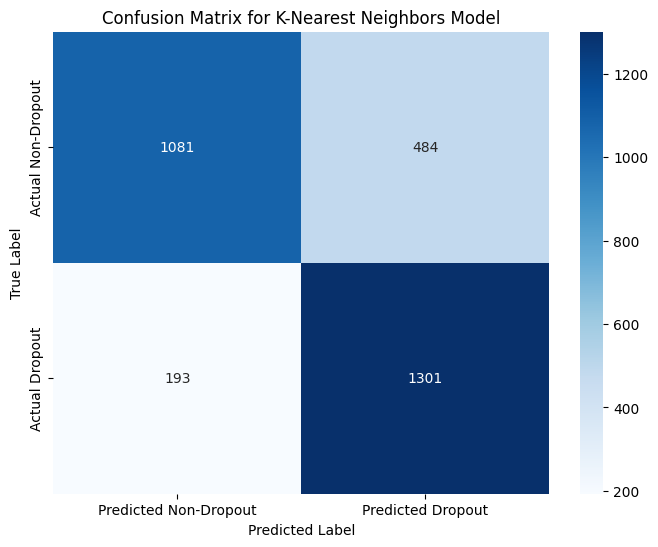

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix for the KNN model
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Confusion Matrix for K-Nearest Neighbors Model:\n", cm_knn)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Dropout', 'Predicted Dropout'],
            yticklabels=['Actual Non-Dropout', 'Actual Dropout'])
plt.title('Confusion Matrix for K-Nearest Neighbors Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

DECISION TREE CLASSIFIER MODEL RUN

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Train a Decision Tree Classifier model
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train_scaled, y_train)

# Make predictions with the DTC model
y_pred_dtc = dtc_model.predict(X_test_scaled)

# Evaluate the DTC model
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
report_dtc = classification_report(y_test, y_pred_dtc)

print(f"Decision Tree Classifier Model Accuracy: {accuracy_dtc:.4f}")
print("Decision Tree Classifier Classification Report:\n", report_dtc)

Decision Tree Classifier Model Accuracy: 0.7349
Decision Tree Classifier Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.71      0.73      1565
           1       0.72      0.76      0.74      1494

    accuracy                           0.73      3059
   macro avg       0.74      0.74      0.73      3059
weighted avg       0.74      0.73      0.73      3059



CONFUSION MATRIX OF DECISION TREE

Confusion Matrix for Decision Tree Classifier Model:
 [[1117  448]
 [ 363 1131]]


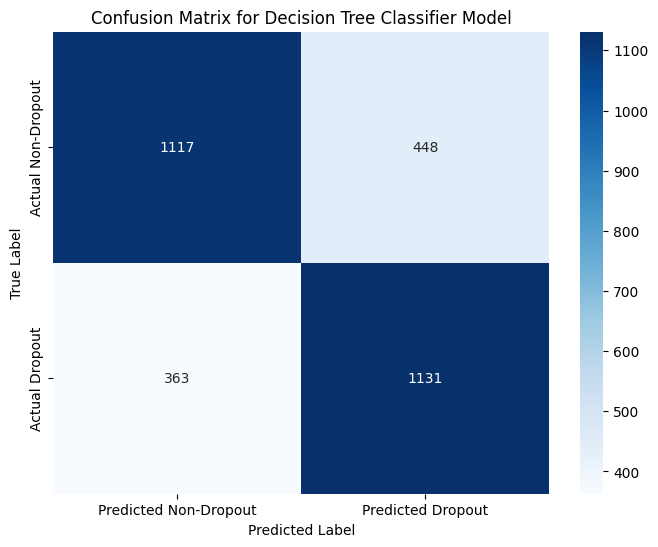

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix for the DTC model
cm_dtc = confusion_matrix(y_test, y_pred_dtc)

print("Confusion Matrix for Decision Tree Classifier Model:\n", cm_dtc)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Dropout', 'Predicted Dropout'],
            yticklabels=['Actual Non-Dropout', 'Actual Dropout'])
plt.title('Confusion Matrix for Decision Tree Classifier Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

xb boost model run


In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize XGBoost model with specific parameters
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# 2. Fit the model to the scaled training data
xgb_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the scaled test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 4. Evaluate performance
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
report_xgb = classification_report(y_test, y_pred_xgb)

print("XGBoost Model Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print("Classification Report:\n", report_xgb)

XGBoost Model Performance:
Accuracy: 0.8310
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      1565
           1       0.82      0.84      0.83      1494

    accuracy                           0.83      3059
   macro avg       0.83      0.83      0.83      3059
weighted avg       0.83      0.83      0.83      3059



confusion matrix of xgb

In [31]:
from sklearn.metrics import confusion_matrix

# 1. Generate predictions using the trained XGBoost model
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 2. Calculate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# 3. Print the confusion matrix
print("Confusion Matrix for XGBoost Model:")
print(cm_xgb)

# Displaying the raw counts
tn, fp, fn, tp = cm_xgb.ravel()
print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

Confusion Matrix for XGBoost Model:
[[1288  277]
 [ 240 1254]]

True Negatives: 1288
False Positives: 277
False Negatives: 240
True Positives: 1254


confusion matrix of xgb

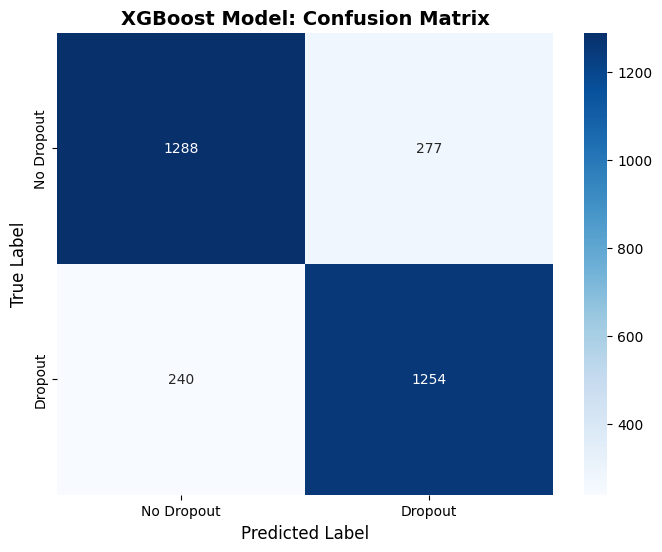

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize a figure with a suitable size
plt.figure(figsize=(8, 6))

# 2. Create a heatmap using seaborn
# cm_xgb was calculated in the previous step
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Dropout', 'Dropout'],
    yticklabels=['No Dropout', 'Dropout']
)

# 3. Add labels and title
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('XGBoost Model: Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Show the plot
plt.show()

pricision recal f1 curve for xgboost

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Instantiate StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Perform cross-validation
cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=skf, scoring='accuracy', n_jobs=-1)

# 3. Calculate and print results
mean_accuracy = cv_scores.mean()
std_accuracy = cv_scores.std()

print("--- Stratified 5-Fold Cross-Validation Results ---")
print(f"Scores per fold: {cv_scores}")
print(f"Mean Accuracy: {mean_accuracy:.4f}")
print(f"Standard Deviation: {std_accuracy:.4f}")

--- Stratified 5-Fold Cross-Validation Results ---
Scores per fold: [0.82141398 0.80915407 0.817736   0.81807032 0.81766149]
Mean Accuracy: 0.8168
Standard Deviation: 0.0041


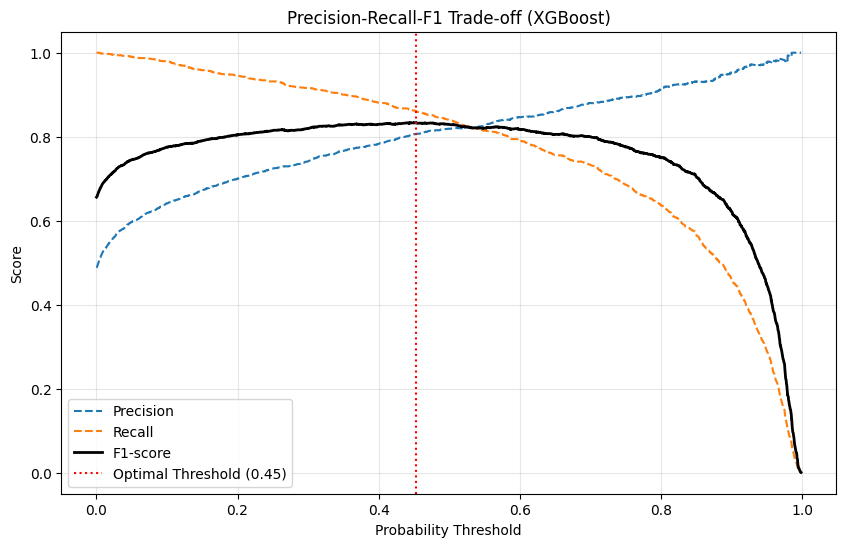

Optimal Threshold for F1-score: 0.4526
Maximum F1-score achieved: 0.8337


In [34]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# 1. Obtain predicted probabilities for the dropout class (class 1)
y_scores_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# 2. Compute precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores_xgb)

# 3. Calculate F1-score for each threshold
# F1 = 2 * (precision * recall) / (precision + recall)
# We add a small epsilon to avoid division by zero
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# 4. Identify the threshold that maximizes the F1-score
# Note: thresholds from precision_recall_curve has len(precision) - 1
ix = np.argmax(f1_scores)
opt_threshold = thresholds[ix] if ix < len(thresholds) else thresholds[-1]
max_f1 = f1_scores[ix]

# 5. Plot Precision, Recall, and F1-score trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', linestyle='--')
plt.plot(thresholds, recall[:-1], label='Recall', linestyle='--')
plt.plot(thresholds, f1_scores[:-1], label='F1-score', linewidth=2, color='black')
plt.axvline(opt_threshold, color='red', linestyle=':', label=f'Optimal Threshold ({opt_threshold:.2f})')

plt.title('Precision-Recall-F1 Trade-off (XGBoost)')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Print results
print(f'Optimal Threshold for F1-score: {opt_threshold:.4f}')
print(f'Maximum F1-score achieved: {max_f1:.4f}')

comparidon table

### Hyperparameter Tuning for XGBoost using RandomizedSearchCV

To further optimize the XGBoost model and potentially achieve higher accuracy, we will perform hyperparameter tuning using `RandomizedSearchCV`. This method efficiently explores a range of hyperparameter combinations to find the best-performing set for our model.

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distribution for RandomizedSearchCV
# These ranges are common starting points for XGBoost tuning
param_distributions = {
    'n_estimators': randint(100, 500),  # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage to prevent overfitting
    'max_depth': randint(3, 10),      # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4),   # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.5),          # Minimum loss reduction required to make a further partition
    'lambda': uniform(1, 2)            # L2 regularization term on weights
}

# Initialize a new XGBoost model instance for tuning
# It's good practice to start with a fresh model for tuning
xgb_tuned = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

# Setup RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Reduce for faster execution if needed.
# cv: Number of cross-validation folds.
# verbose: Controls the verbosity: the higher, the more messages.
random_search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_distributions,
    n_iter=50, # Number of different combinations to try, can increase for more thorough search
    cv=5,       # 5-fold cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,  # Use all available cores
    verbose=1
)

print("Starting RandomizedSearchCV for XGBoost...")
random_search.fit(X_train_scaled, y_train)
print("RandomizedSearchCV completed.")

Starting RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:48:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV completed.



Best parameters found: {'colsample_bytree': np.float64(0.9400154311159197), 'gamma': np.float64(0.2247253370691017), 'lambda': np.float64(1.1908202329808226), 'learning_rate': np.float64(0.1212454756594799), 'max_depth': 8, 'n_estimators': 315, 'subsample': np.float64(0.8663689426469987)}
Best cross-validation accuracy: 0.8361807021864343

Tunned XGBoost Model Accuracy (on test set): 0.8477
Tunned XGBoost Classification Report (on test set):
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      1565
           1       0.84      0.85      0.85      1494

    accuracy                           0.85      3059
   macro avg       0.85      0.85      0.85      3059
weighted avg       0.85      0.85      0.85      3059



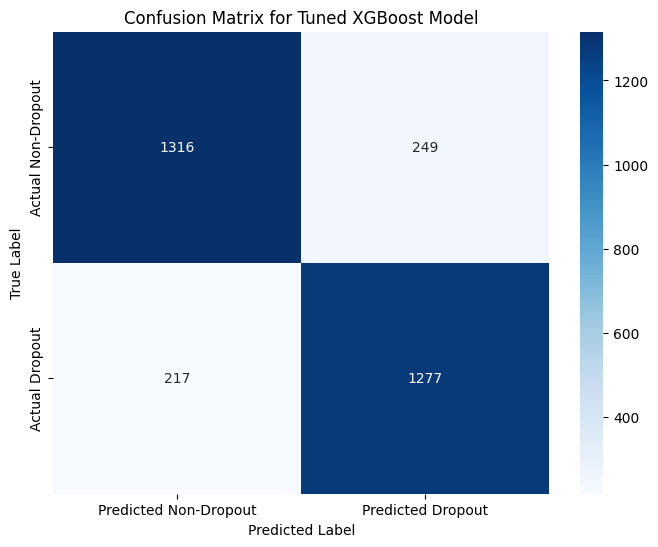

In [36]:
# Display the best parameters and best score
print("\nBest parameters found:", random_search.best_params_)
print("Best cross-validation accuracy:", random_search.best_score_)

# Get the best estimator (the tuned model)
best_xgb_model = random_search.best_estimator_

# Make predictions with the best model
y_pred_tuned_xgb = best_xgb_model.predict(X_test_scaled)

# Evaluate the tuned model
accuracy_tuned_xgb = accuracy_score(y_test, y_pred_tuned_xgb)
report_tuned_xgb = classification_report(y_test, y_pred_tuned_xgb)

print(f"\nTunned XGBoost Model Accuracy (on test set): {accuracy_tuned_xgb:.4f}")
print("Tunned XGBoost Classification Report (on test set):\n", report_tuned_xgb)

# Plot Confusion Matrix for Tuned XGBoost Model
cm_tuned_xgb = confusion_matrix(y_test, y_pred_tuned_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Dropout', 'Predicted Dropout'],
            yticklabels=['Actual Non-Dropout', 'Actual Dropout'])
plt.title('Confusion Matrix for Tuned XGBoost Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

FEATURE IMPORTANCE OF XGBOOST

In [45]:
# Get feature importances from the tuned model
feature_importances_tuned_xgb = best_xgb_model.feature_importances_

# Define original_feature_names if not already defined
# This variable should contain the names of features from the preprocessed data (X_encoded)
if 'original_feature_names' not in globals():
    # Assuming X_encoded is available and contains the original feature set
    original_feature_names = X_encoded.columns.tolist()

# Create a DataFrame for better visualization
importance_df_tuned_xgb = pd.DataFrame({
    'Feature': original_feature_names,
    'Importance': feature_importances_tuned_xgb
})

# Sort the features by importance in descending order
importance_df_tuned_xgb = importance_df_tuned_xgb.sort_values(by='Importance', ascending=False)

# Display the top 15 most important features for the Tuned XGBoost model
print("Top 15 Feature Importances for Tuned XGBoost Model:")
display(importance_df_tuned_xgb.head(15))


Top 15 Feature Importances for Tuned XGBoost Model:


,Feature,Importance
12,GPA,0.139554
4,Internet_Access,0.109828
13,Semester_GPA,0.091777
10,Scholarship,0.081944
2,Gender,0.080133
17,Parental_Education,0.050664
15,Semester,0.048369
9,Part_Time_Job,0.044224
11,Stress_Index,0.041925
16,Department,0.041375


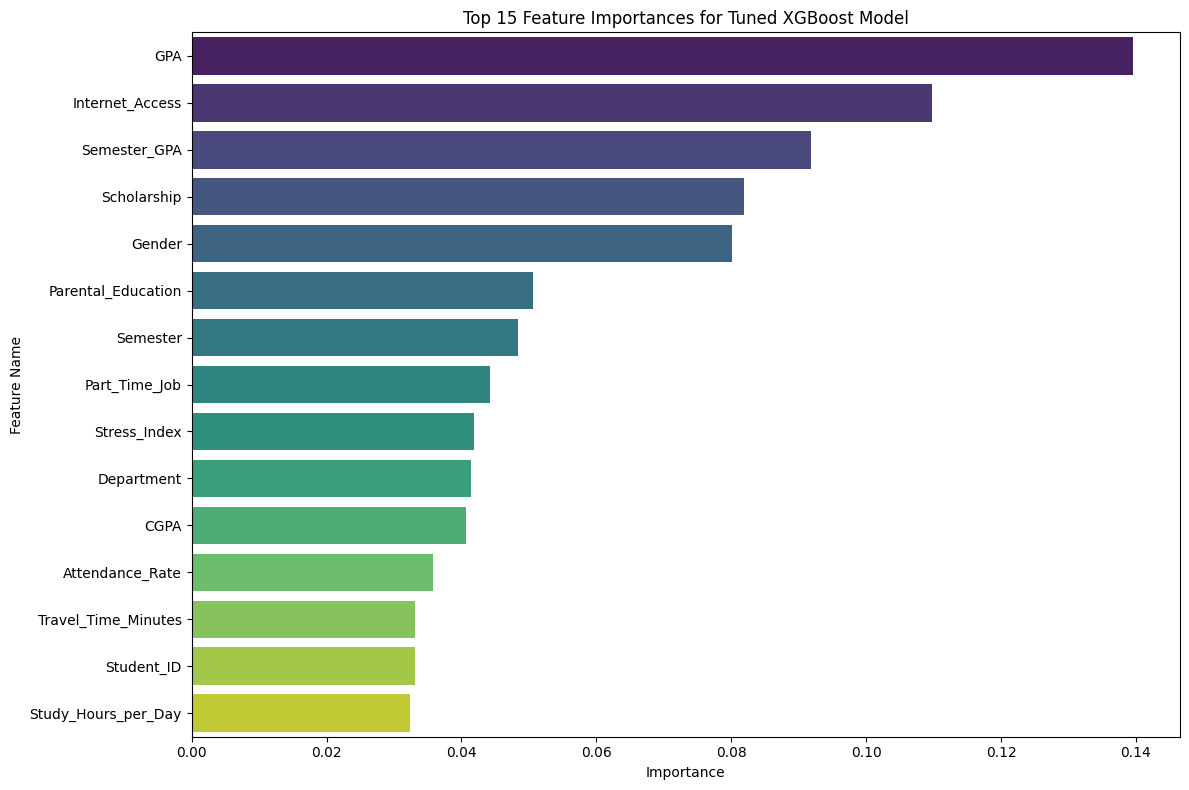

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_tuned_xgb.head(15), palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Feature Importances for Tuned XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

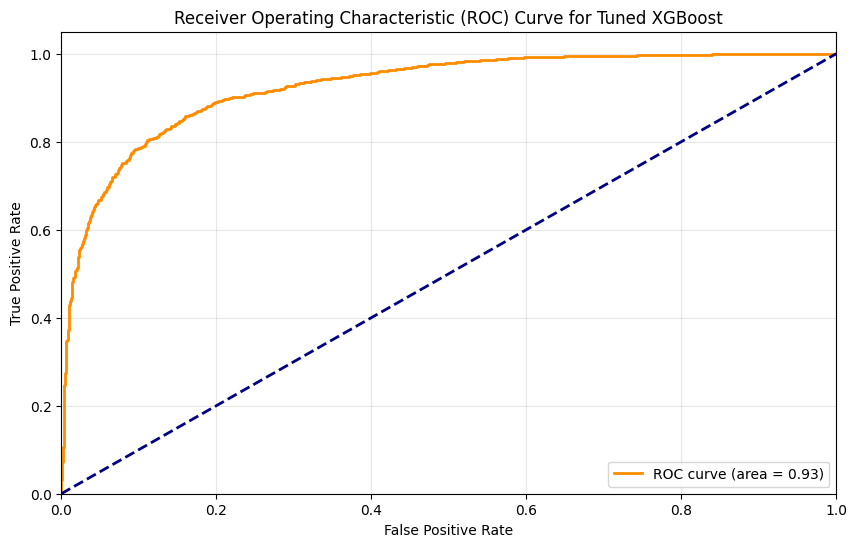

Tuned XGBoost ROC AUC: 0.9257


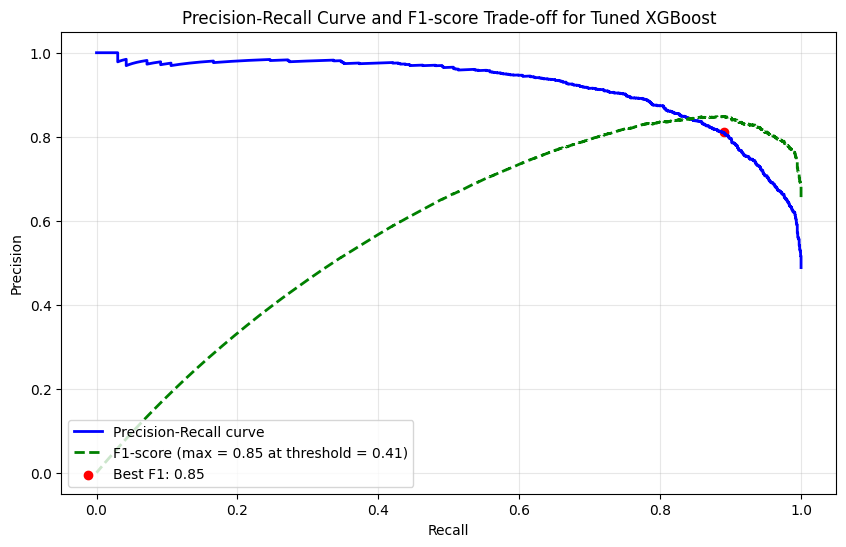

Optimal Threshold for F1-score (Tuned XGBoost): 0.4096
Maximum F1-score achieved (Tuned XGBoost): 0.8485


In [48]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get predicted probabilities for the positive class (Dropout = 1)
y_scores_tuned_xgb = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

# --- 1. ROC AUC Curve ---

fpr, tpr, thresholds_roc = roc_curve(y_test, y_scores_tuned_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned XGBoost')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Tuned XGBoost ROC AUC: {roc_auc:.4f}")

# --- 2. Precision-Recall Curve & F1-score Trade-off ---

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores_tuned_xgb)

# Calculate F1-score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Find the optimal threshold that maximizes the F1-score
ix = np.argmax(f1_scores)
opt_threshold_pr = thresholds_pr[ix] if ix < len(thresholds_pr) else thresholds_pr[-1]
max_f1_pr = f1_scores[ix]

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.plot(recall, f1_scores, color='green', lw=2, linestyle='--', label=f'F1-score (max = {max_f1_pr:.2f} at threshold = {opt_threshold_pr:.2f})')
plt.scatter(recall[ix], precision[ix], marker='o', color='red', label=f'Best F1: {max_f1_pr:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve and F1-score Trade-off for Tuned XGBoost')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

print(f'Optimal Threshold for F1-score (Tuned XGBoost): {opt_threshold_pr:.4f}')
print(f'Maximum F1-score achieved (Tuned XGBoost): {max_f1_pr:.4f}')

### Building a Hybrid Model (Ensemble) with Voting Classifier

To further improve predictive performance and robustness, we will create a hybrid model by combining the XGBoost Classifier (your top-performing model) and the Random Forest Classifier (your second-best model) using a Voting Classifier. This ensemble technique leverages the strengths of multiple models by combining their predictions. We'll use 'soft' voting, which considers the predicted probabilities from each model.

In [49]:
from sklearn.ensemble import VotingClassifier

# 1. Define the individual models
# xgb_model and model (RandomForestClassifier) are already trained.

# 2. Create the VotingClassifier
# Assign names to the estimators for clarity.
# Use 'soft' voting to average predicted probabilities.
# You can optionally assign weights based on individual model performance (e.g., more weight to XGBoost).
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb_model), # NOW using the best tuned XGBoost model
        ('rf', model) # 'model' is your RandomForestClassifier
    ],
    voting='soft', # Use soft voting for probabilistic predictions
    weights=[0.6, 0.4], # Example weights: giving more importance to XGBoost
    n_jobs=-1 # Use all available cores for parallel processing
)

print("Training Voting Classifier...")
voting_clf.fit(X_train_scaled, y_train)
print("Voting Classifier training complete.")

Training Voting Classifier...
Voting Classifier training complete.


Hybrid Model Accuracy: 0.8428
Hybrid Model Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      1565
           1       0.83      0.85      0.84      1494

    accuracy                           0.84      3059
   macro avg       0.84      0.84      0.84      3059
weighted avg       0.84      0.84      0.84      3059



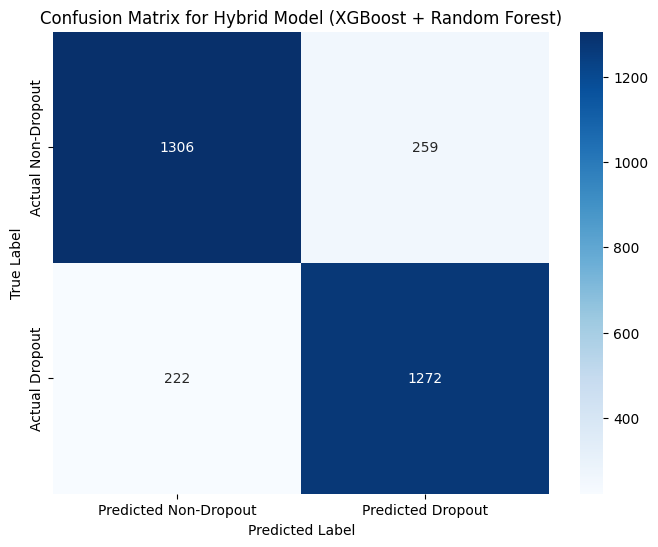

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions with the Voting Classifier
y_pred_hybrid = voting_clf.predict(X_test_scaled)

# Evaluate the hybrid model
accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
report_hybrid = classification_report(y_test, y_pred_hybrid)
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)

print(f"Hybrid Model Accuracy: {accuracy_hybrid:.4f}")
print("Hybrid Model Classification Report:\n", report_hybrid)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Dropout', 'Predicted Dropout'],
            yticklabels=['Actual Non-Dropout', 'Actual Dropout'])
plt.title('Confusion Matrix for Hybrid Model (XGBoost + Random Forest)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [51]:
import pandas as pd
import io

def parse_classification_report_for_class_1(report_str):
    report_data = io.StringIO(report_str)
    lines = report_data.readlines()
    metrics = {'precision': None, 'recall': None, 'f1-score': None}
    for line in lines:
        # Look for the line corresponding to class '1'
        if line.strip().startswith('1 ') and len(line.strip().split()) >= 4:
            parts = line.strip().split()
            metrics['precision'] = float(parts[1])
            metrics['recall'] = float(parts[2])
            metrics['f1-score'] = float(parts[3])
            break
    return metrics

# Retrieve the metrics for class 1 (Dropout) from each classification report string
rf_metrics_1 = parse_classification_report_for_class_1(report)
logistic_metrics_1 = parse_classification_report_for_class_1(report_logistic)
svm_metrics_1 = parse_classification_report_for_class_1(report_svm)
knn_metrics_1 = parse_classification_report_for_class_1(report_knn)
dtc_metrics_1 = parse_classification_report_for_class_1(report_dtc)
xgb_metrics_1 = parse_classification_report_for_class_1(report_xgb)
hybrid_metrics_1 = parse_classification_report_for_class_1(report_hybrid) # This will be the *updated* hybrid report
tuned_xgb_metrics_1 = parse_classification_report_for_class_1(report_tuned_xgb)

# Ensure stacking_metrics_1 is defined; if not, set default values or handle appropriately
# Based on the notebook state, report_stacking and accuracy_stacking exist and are used in data dict.
# If this is the last run of the notebook, they should be fine.
# Assuming report_stacking and accuracy_stacking are available as per context.
# Create the DataFrame for model comparison
data = {
    'Model': ['Random Forest', 'Logistic Regression', 'SVC', 'K-Nearest Neighbors', 'Decision Tree', 'XGBoost', 'Hybrid (XGB+RF)', 'Tuned XGBoost',],
    'Accuracy': [accuracy, accuracy_logistic, accuracy_svm, accuracy_knn, accuracy_dtc, accuracy_xgb, accuracy_hybrid, accuracy_tuned_xgb,],
    'Precision': [rf_metrics_1['precision'], logistic_metrics_1['precision'], svm_metrics_1['precision'], knn_metrics_1['precision'], dtc_metrics_1['precision'], xgb_metrics_1['precision'], hybrid_metrics_1['precision'], tuned_xgb_metrics_1['precision']],
    'Recall': [rf_metrics_1['recall'], logistic_metrics_1['recall'], svm_metrics_1['recall'], knn_metrics_1['recall'], dtc_metrics_1['recall'], xgb_metrics_1['recall'], hybrid_metrics_1['recall'], tuned_xgb_metrics_1['recall']],
    'F1-score': [rf_metrics_1['f1-score'], logistic_metrics_1['f1-score'], svm_metrics_1['f1-score'], knn_metrics_1['f1-score'], dtc_metrics_1['f1-score'], xgb_metrics_1['f1-score'], hybrid_metrics_1['f1-score'], tuned_xgb_metrics_1['f1-score']]
}
metrics_df = pd.DataFrame(data)

# Display the comparison table of all model metrics without sorting by accuracy
print("Summary of Model Performance (Class 1: Dropout):")
display(metrics_df.style.background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall', 'F1-score']))

Summary of Model Performance (Class 1: Dropout):


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.813665,0.800000,0.830000,0.810000
1,Logistic Regression,0.789801,0.770000,0.810000,0.790000
2,SVC,0.808434,0.790000,0.820000,0.810000
3,K-Nearest Neighbors,0.778686,0.730000,0.870000,0.790000
4,Decision Tree,0.734881,0.720000,0.760000,0.740000
5,XGBoost,0.830991,0.820000,0.840000,0.830000
6,Hybrid (XGB+RF),0.842759,0.830000,0.850000,0.840000
7,Tuned XGBoost,0.847663,0.840000,0.850000,0.850000


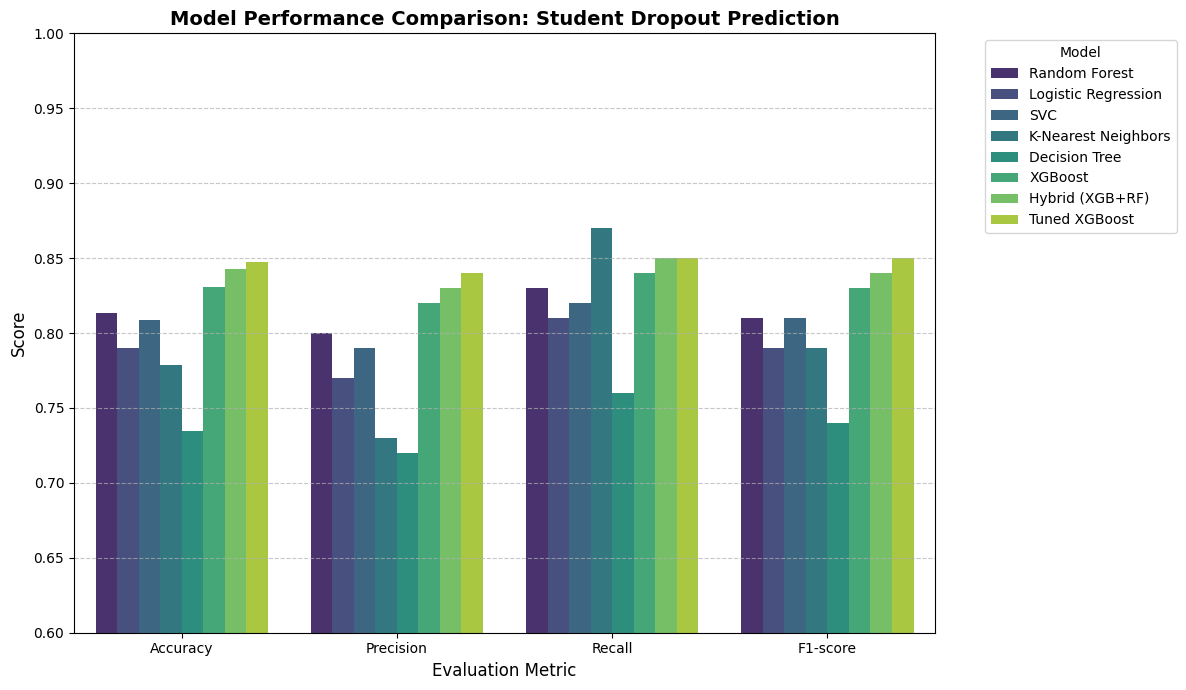

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Reshape metrics_df into long-form format using pd.melt
metrics_long = pd.melt(
    metrics_df,
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

# 2. Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_long, palette='viridis')

# 3. Set plot aesthetics and axis limits
plt.ylim(0.6, 1.0)
plt.title('Model Performance Comparison: Student Dropout Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)

# 4. Position legend outside for clarity
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 5. Display the plot
plt.show()

top 4 model compare

### Top 4 Model Comparison

Based on the performance metrics summarized previously, let's identify and visualize the top 4 models to highlight their strengths across different metrics.


In [53]:
import pandas as pd

# Check if metrics_df is defined
if 'metrics_df' not in globals():
    raise NameError("Variable 'metrics_df' is not defined. Please ensure that cell '94007288' (Summary of Model Performance) has been executed to create this DataFrame.")

# Sort the metrics_df by Accuracy in descending order and select the top 4 models
top_4_models_df = metrics_df.sort_values(by='Accuracy', ascending=False).head(4)

print("Top 4 Models by Accuracy:")
display(top_4_models_df)


Top 4 Models by Accuracy:


,Model,Accuracy,Precision,Recall,F1-score
7,Tuned XGBoost,0.847663,0.84,0.85,0.85
6,Hybrid (XGB+RF),0.842759,0.83,0.85,0.84
5,XGBoost,0.830991,0.82,0.84,0.83
0,Random Forest,0.813665,0.80,0.83,0.81


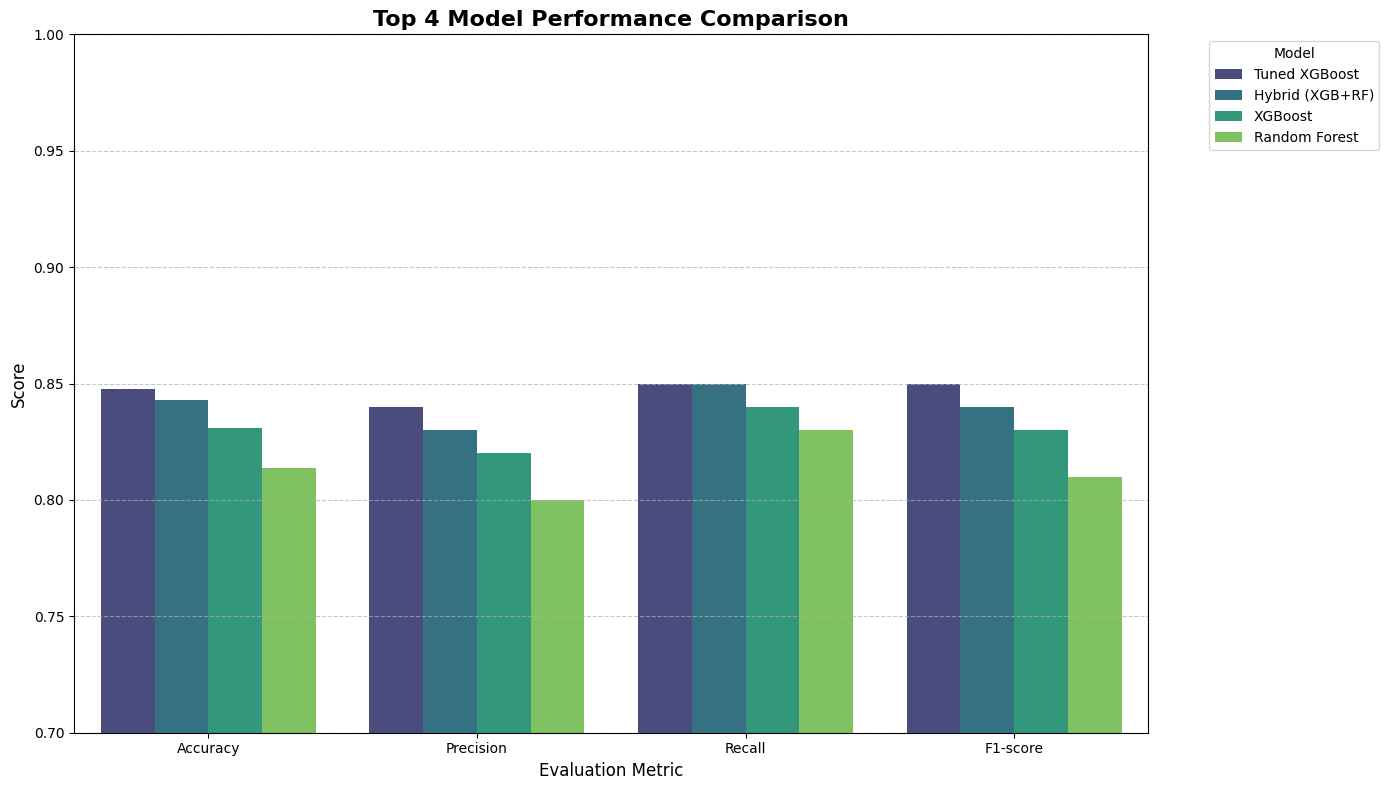

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reshape the top 4 models DataFrame for plotting
top_4_models_long = pd.melt(top_4_models_df,
                            id_vars='Model',
                            var_name='Metric',
                            value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score'],
                            value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=top_4_models_long, palette='viridis')

plt.ylim(0.7, 1.0) # Adjust y-axis for better visibility of differences
plt.title('Top 4 Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Feature Importance — Consensus Ranking

To get a more robust understanding of feature importance, we combine the importances from several models. We'll normalize the importances from each model and then calculate a mean importance score across them. SVC and KNN models do not directly provide feature importances in a straightforward manner, so they will not be included in this consensus.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if X_encoded is defined; if not, raise an informative error.
# X_encoded is created in cell 'de54ab51' after one-hot encoding.
if 'X_encoded' not in globals():
    raise NameError("Variable 'X_encoded' is not defined. Please ensure that all preceding data preprocessing cells, especially cell 'de54ab51' (Apply Balancing), have been executed.")

# Get feature names from the encoded training data (X_encoded is from cell 'de54ab51')
feature_names = X_encoded.columns.tolist()

# Initialize a dictionary to store normalized importances from each model
all_importances = {}

# --- Random Forest Feature Importances (from 'model' in cell '78c42c7c') ---
if hasattr(model, 'feature_importances_'):
    rf_importance = model.feature_importances_
    if rf_importance.sum() > 0:
        all_importances['RandomForest'] = rf_importance / rf_importance.sum()
    else:
        all_importances['RandomForest'] = np.zeros_like(rf_importance) # Handle cases where sum is zero

# --- Logistic Regression Feature Importances (coefficients from 'logistic_model' in cell 'd59c29a3') ---
# Absolute values are used as coefficients can be negative but still indicate importance
if hasattr(logistic_model, 'coef_'):
    lr_importance = np.abs(logistic_model.coef_[0])
    if lr_importance.sum() > 0:
        all_importances['LogisticRegression'] = lr_importance / lr_importance.sum()
    else:
        all_importances['LogisticRegression'] = np.zeros_like(lr_importance)

# --- Decision Tree Feature Importances (from 'dtc_model' in cell '8149f87b') ---
if hasattr(dtc_model, 'feature_importances_'):
    dtc_importance = dtc_model.feature_importances_
    if dtc_importance.sum() > 0:
        all_importances['DecisionTree'] = dtc_importance / dtc_importance.sum()
    else:
        all_importances['DecisionTree'] = np.zeros_like(dtc_importance)

# --- Tuned XGBoost Feature Importances (from 'best_xgb_model' in cell '699d94d8') ---
if hasattr(best_xgb_model, 'feature_importances_'):
    xgb_importance = best_xgb_model.feature_importances_
    if xgb_importance.sum() > 0:
        all_importances['XGBoost'] = xgb_importance / xgb_importance.sum()
    else:
        all_importances['XGBoost'] = np.zeros_like(xgb_importance)

# Create a DataFrame from the collected importances
# Ensure all importance arrays have the same length as feature_names

# First, align all importance arrays to have the same length as feature_names
# This loop also serves as a check to remove any invalid importance arrays
valid_all_importances = {}
for model_name, importance_array in all_importances.items():
    if len(importance_array) == len(feature_names):
        valid_all_importances[model_name] = importance_array
    else:
        print(f"Warning: {model_name} importances length mismatch. Skipping for consensus.")

if not valid_all_importances:
    print("No valid feature importances found from models to create consensus.")
    consensus_ranking = pd.DataFrame(columns=['Mean_Importance'])
else:
    importance_df = pd.DataFrame(valid_all_importances, index=feature_names)

    # Calculate the mean importance across all models for each feature
    importance_df['Mean_Importance'] = importance_df.mean(axis=1)

    # Sort by mean importance in descending order
    consensus_ranking = importance_df.sort_values(by='Mean_Importance', ascending=False)

print("Consensus Feature Importance Ranking (Mean Normalized Importance):")
display(consensus_ranking[['Mean_Importance']].head(10))

Consensus Feature Importance Ranking (Mean Normalized Importance):


,Mean_Importance
GPA,0.245554
Semester_GPA,0.072320
Stress_Index,0.067097
CGPA,0.060614
Attendance_Rate,0.059178
Internet_Access,0.054533
Scholarship,0.048459
Gender,0.047842
Travel_Time_Minutes,0.043743
Student_ID,0.039601


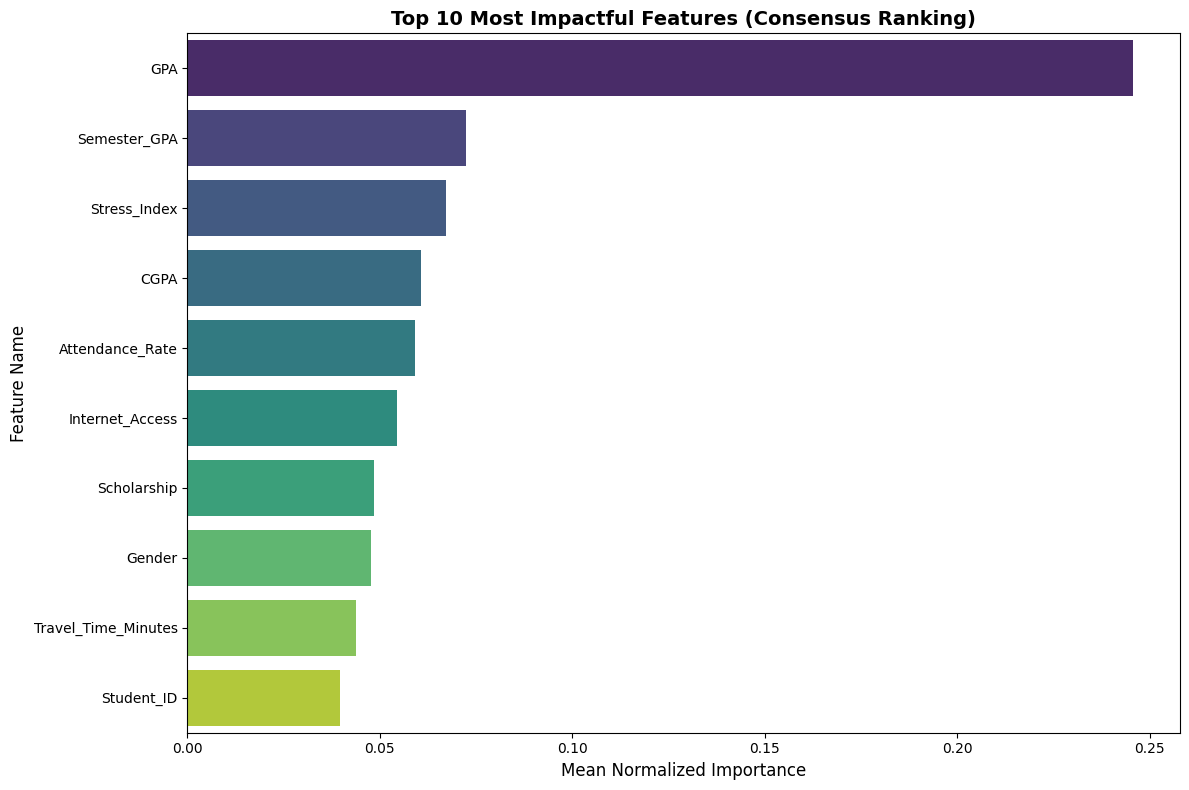

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

if not consensus_ranking.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Mean_Importance', y=consensus_ranking.index[:10], data=consensus_ranking.head(10),
                palette='viridis', hue=consensus_ranking.index[:10], legend=False)
    plt.title('Top 10 Most Impactful Features (Consensus Ranking)', fontsize=14, fontweight='bold')
    plt.xlabel('Mean Normalized Importance', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No features to plot for consensus ranking.")

### Feature Importance — Consensus Ranking

To get a more robust understanding of feature importance, we will combine the importances from several models. We'll normalize the importances from each model and then calculate a mean importance score across them. SVC and KNN models do not directly provide feature importances in a straightforward manner, so they will not be included in this consensus.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if X_encoded is defined; if not, raise an informative error.
# X_encoded is created in cell 'de54ab51' after one-hot encoding.
if 'X_encoded' not in globals():
    raise NameError("Variable 'X_encoded' is not defined. Please ensure that all preceding data preprocessing cells, especially cell 'de54ab51' (Apply Balancing), have been executed.")

# Get feature names from the encoded training data (X_encoded is from cell 'de54ab51')
feature_names = X_encoded.columns.tolist()

# Initialize a dictionary to store normalized importances from each model
all_importances = {}

# --- Random Forest Feature Importances (from 'model' in cell '78c42c7c') ---
if hasattr(model, 'feature_importances_'):
    rf_importance = model.feature_importances_
    if rf_importance.sum() > 0:
        all_importances['RandomForest'] = rf_importance / rf_importance.sum()
    else:
        all_importances['RandomForest'] = np.zeros_like(rf_importance) # Handle cases where sum is zero

# --- Logistic Regression Feature Importances (coefficients from 'logistic_model' in cell 'd59c29a3') ---
# Absolute values are used as coefficients can be negative but still indicate importance
if hasattr(logistic_model, 'coef_'):
    lr_importance = np.abs(logistic_model.coef_[0])
    if lr_importance.sum() > 0:
        all_importances['LogisticRegression'] = lr_importance / lr_importance.sum()
    else:
        all_importances['LogisticRegression'] = np.zeros_like(lr_importance)

# --- Decision Tree Feature Importances (from 'dtc_model' in cell '8149f87b') ---
if hasattr(dtc_model, 'feature_importances_'):
    dtc_importance = dtc_model.feature_importances_
    if dtc_importance.sum() > 0:
        all_importances['DecisionTree'] = dtc_importance / dtc_importance.sum()
    else:
        all_importances['DecisionTree'] = np.zeros_like(dtc_importance)

# --- Tuned XGBoost Feature Importances (from 'best_xgb_model' in cell '699d94d8') ---
if hasattr(best_xgb_model, 'feature_importances_'):
    xgb_importance = best_xgb_model.feature_importances_
    if xgb_importance.sum() > 0:
        all_importances['XGBoost'] = xgb_importance / xgb_importance.sum()
    else:
        all_importances['XGBoost'] = np.zeros_like(xgb_importance)

# Create a DataFrame from the collected importances
# Ensure all models have the same features and shape, pad with zeros if any model is missing
# This robustness check is good practice, though typically all models should fit the same X_encoded.

# First, align all importance arrays to have the same length as feature_names
for model_name, importance_array in all_importances.items():
    if len(importance_array) != len(feature_names):
        print(f"Warning: {model_name} importances length mismatch. Skipping.")
        del all_importances[model_name]

if not all_importances:
    print("No valid feature importances found from models to create consensus.")
    consensus_ranking = pd.DataFrame(columns=['Mean_Importance'])
else:
    importance_df = pd.DataFrame(all_importances, index=feature_names)

    # Calculate the mean importance across all models for each feature
    importance_df['Mean_Importance'] = importance_df.mean(axis=1)

    # Sort by mean importance in descending order
    consensus_ranking = importance_df.sort_values(by='Mean_Importance', ascending=False)

print("Consensus Feature Importance Ranking (Mean Normalized Importance):")
display(consensus_ranking[['Mean_Importance']].head(10))


Consensus Feature Importance Ranking (Mean Normalized Importance):


,Mean_Importance
GPA,0.245554
Semester_GPA,0.072320
Stress_Index,0.067097
CGPA,0.060614
Attendance_Rate,0.059178
Internet_Access,0.054533
Scholarship,0.048459
Gender,0.047842
Travel_Time_Minutes,0.043743
Student_ID,0.039601


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

if not consensus_ranking.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Mean_Importance', y=consensus_ranking.index[:10], data=consensus_ranking.head(10),
                palette='viridis', hue=consensus_ranking.index[:10], legend=False)
    plt.title('Top 10 Most Impactful Features (Consensus Ranking)', fontsize=14, fontweight='bold')
    plt.xlabel('Mean Normalized Importance', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No features to plot for consensus ranking.")


NameError: name 'consensus_ranking' is not defined

In [ ]:
!pip install shap

xgb model er jonno shap ta

Calculating corrected SHAP values...
Generating SHAP Summary Plot...


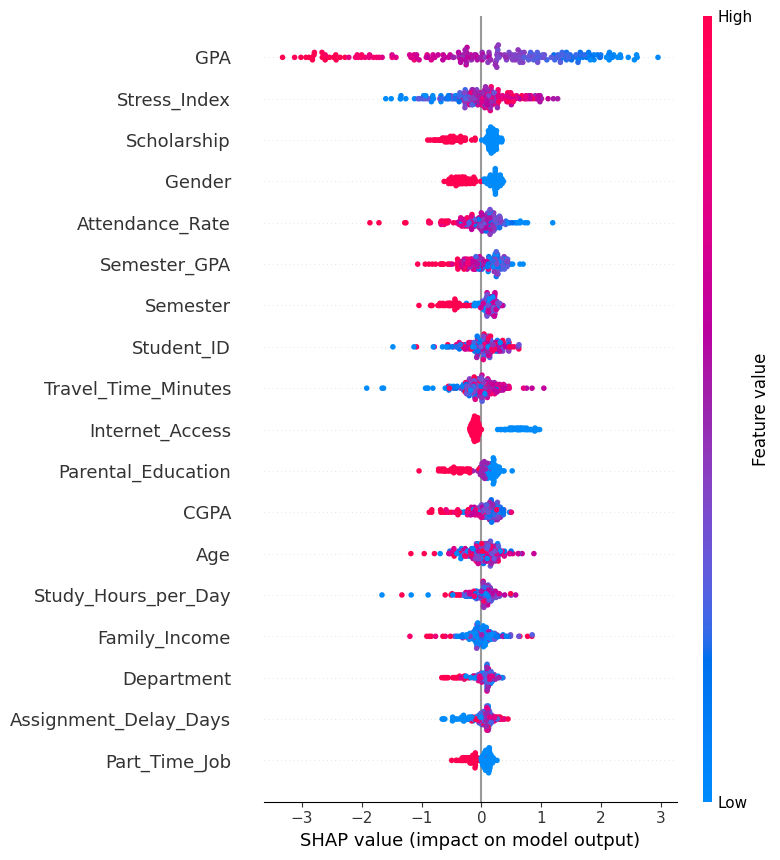


Generating SHAP Waterfall Plot for Sample 0...


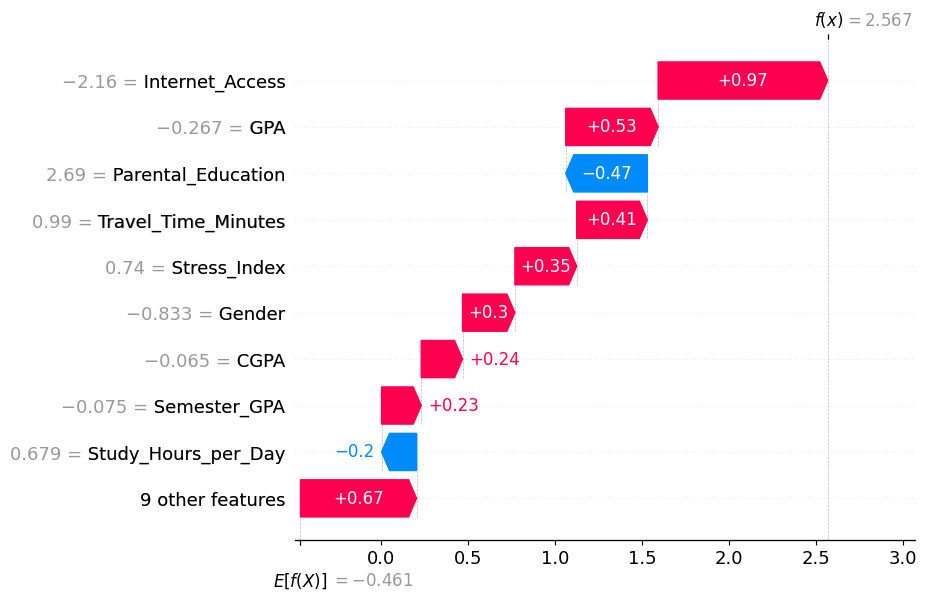

In [ ]:
import shap

# 1. Identify the original 18 features used for the initial XGBoost model
# X_encoded (18 features) was used to train xgb_model
original_feature_names = X_encoded.columns.tolist()

# 2. Re-initialize the explainer with the correct feature names
explainer_fixed = shap.Explainer(xgb_model, X_train_scaled[:100], feature_names=original_feature_names)

# 3. Calculate SHAP values specifically for the subset
print("Calculating corrected SHAP values...")
shap_values_fixed = explainer_fixed(X_test_scaled[:200])

# 4. Generate SHAP Summary Plot
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values_fixed, X_test_scaled[:200], feature_names=original_feature_names)

# 5. Generate SHAP Waterfall Plot for the first sample
print("\nGenerating SHAP Waterfall Plot for Sample 0...")
shap.plots.waterfall(shap_values_fixed[0])

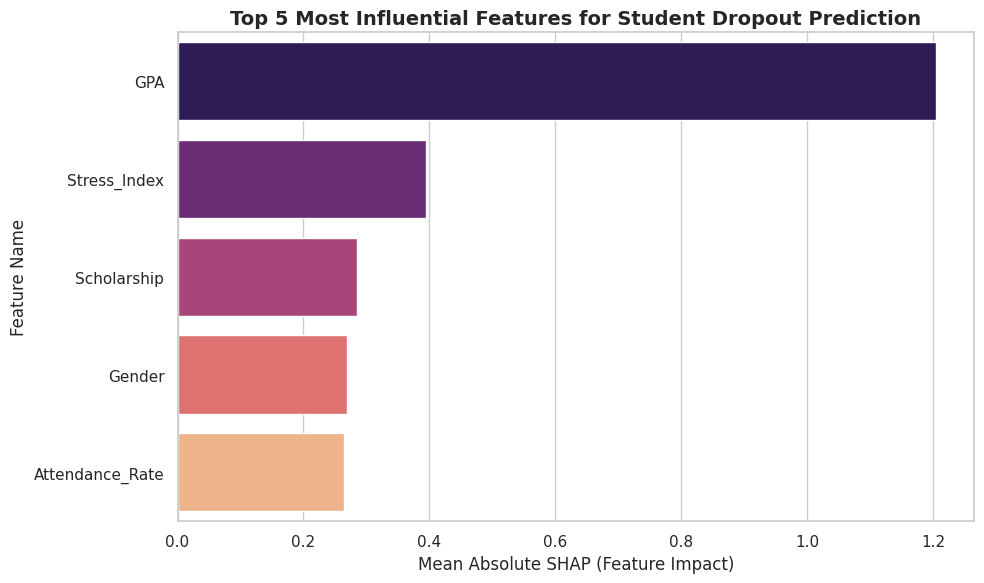

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a professional plotting style
sns.set_theme(style='whitegrid')

# 2. Create the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Mean_Abs_SHAP',
    y='Feature',
    data=top_5_shap_features,
    hue='Feature',
    palette='magma',
    legend=False
)

# 3. Add labels and title
plt.xlabel('Mean Absolute SHAP (Feature Impact)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.title('Top 5 Most Influential Features for Student Dropout Prediction', fontsize=14, fontweight='bold')

# 4. Final adjustments and display
plt.tight_layout()
plt.show()

In [ ]:
arimport numpy as np
import pandas as pd

# 1. Access the values attribute and calculate absolute SHAP values
abs_shap_values = np.abs(shap_values_fixed.values)

# 2. Calculate the mean across all samples (axis 0)
mean_abs_shap = abs_shap_values.mean(axis=0)

# 3. Combine with feature names into a DataFrame
shap_importance_df = pd.DataFrame({
    'Feature': original_feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
})

# 4. Sort in descending order and select top 5
top_5_shap_features = shap_importance_df.sort_values(by='Mean_Abs_SHAP', ascending=False).head(5)

print("Top 5 Most Influential Features (SHAP):")
display(top_5_shap_features)

Top 5 Most Influential Features (SHAP):


,Feature,Mean_Abs_SHAP
12,GPA,1.205016
11,Stress_Index,0.394878
10,Scholarship,0.284606
2,Gender,0.269972
6,Attendance_Rate,0.264891


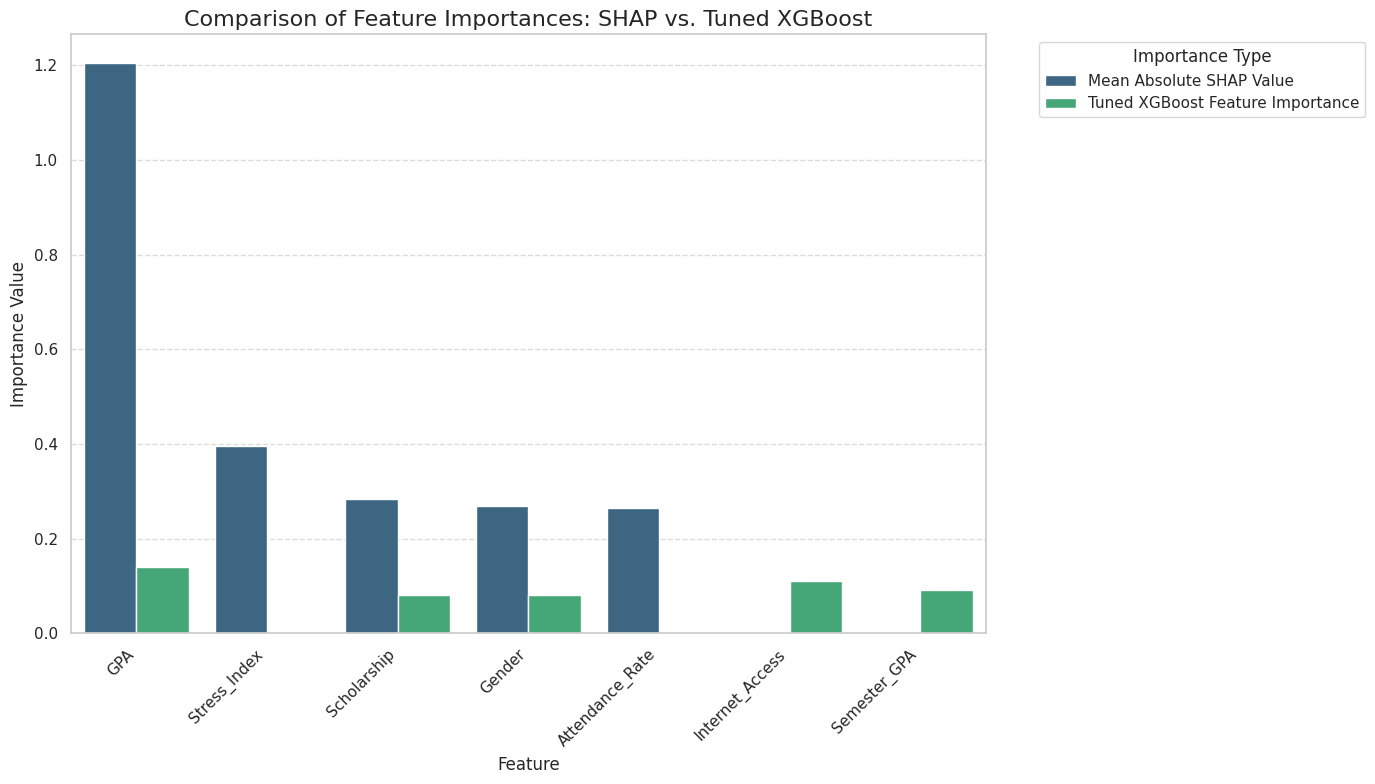

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting: melt the DataFrame to long format
# We need to handle potential NaN values if a feature was not in the top 5 for both methods
plot_df = combined_importance_df.melt(id_vars=['Feature'],
                                       value_vars=['Mean_Abs_SHAP', 'Importance'],
                                       var_name='Importance_Type',
                                       value_name='Value')

# Rename importance types for better legend labels
plot_df['Importance_Type'] = plot_df['Importance_Type'].replace({
    'Mean_Abs_SHAP': 'Mean Absolute SHAP Value',
    'Importance': 'Tuned XGBoost Feature Importance'
})

# Create the grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='Feature', y='Value', hue='Importance_Type', data=plot_df,
            palette='viridis')

plt.title('Comparison of Feature Importances: SHAP vs. Tuned XGBoost', fontsize=16)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Importance Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

important feature of shape

random value test

--- Randomly Generated Student Profile ---


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education
3671,3672,22.9,1,26884.0,1,1.22,82.6,0,32.6,0,0,4.1,1.44,1.16,1.24,3,3,1



Predicted Dropout Probability: 18.47%
Predicted Class: No Dropout (0)

--- SHAP Waterfall Plot for the Prediction ---


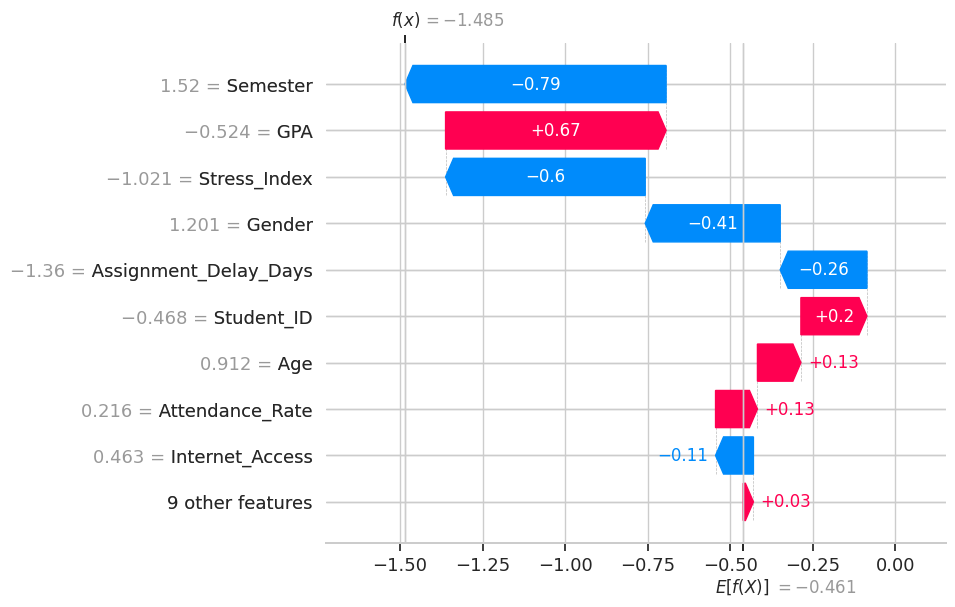

In [ ]:
import shap
import numpy as np
import pandas as pd

def predict_and_explain_random_student(xgb_model, explainer, scaler, X_ref, encoders):
    """
    Generates a random student profile, predicts dropout probability, and explains
    the prediction using SHAP.

    Args:
        xgb_model: Trained XGBoost model.
        explainer: SHAP Explainer object.
        scaler: Fitted StandardScaler object.
        X_ref: Original (unscaled, encoded) DataFrame for feature reference.
        encoders: Dictionary of LabelEncoders (not directly used for new random profile in this setup,
                  but kept for consistency if profile generation were more complex).

    Returns:
        tuple: (random_profile_df, probability, predicted_class, shap_values_single_sample)
    """
    # 1. Select a random sample from the reference data
    random_idx = np.random.randint(0, len(X_ref))
    random_profile_df = X_ref.iloc[[random_idx]].copy()

    # 2. Preprocess the random profile: scale numerical features
    # The scaler expects a 2D array, even for a single sample
    scaled_profile = scaler.transform(random_profile_df)

    # 3. Predict dropout probability and class
    probability = xgb_model.predict_proba(scaled_profile)[:, 1][0]
    predicted_class = xgb_model.predict(scaled_profile)[0]

    # 4. Calculate SHAP values for the single random sample
    # The explainer was created with X_train_scaled, so it expects scaled input
    shap_values_single_sample = explainer(scaled_profile)

    return random_profile_df, probability, predicted_class, shap_values_single_sample

# 1. Execute the function to get random profile, probability, class, and SHAP values
random_profile, prob, pred_class, shap_vals_single = predict_and_explain_random_student(
    xgb_model=xgb_model,
    explainer=explainer_fixed,
    scaler=scaler,
    X_ref=X_encoded,
    encoders=label_encoders
)

# 2. Print the profile and prediction results
print("--- Randomly Generated Student Profile ---")
display(random_profile)

print(f"\nPredicted Dropout Probability: {prob:.2%}")
print(f"Predicted Class: {'Dropout' if pred_class == 1 else 'No Dropout'} ({pred_class})")

# 3. Visualize the SHAP explanation using a waterfall plot
print("\n--- SHAP Waterfall Plot for the Prediction ---")
shap.plots.waterfall(shap_vals_single[0])

random value testing

--- New Randomly Generated Student Profile ---


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education
6882,6883,19.4,0,61675.0,1,2.5,73.7,1,45.8,0,1,7.1,0.67,0.91,0.89,1,0,0



Predicted Dropout Probability: 97.20%
Predicted Class: Dropout (1)

--- SHAP Waterfall Plot for the New Prediction ---


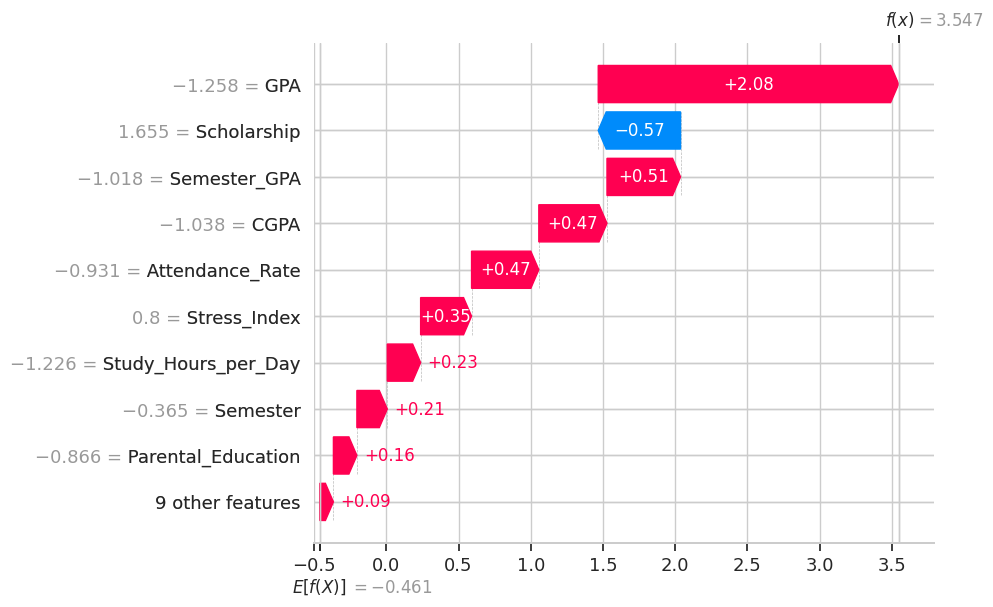

In [ ]:
import shap

# 1. Generate new random prediction and explanation
random_profile_new, prob_new, pred_class_new, shap_vals_new = predict_and_explain_random_student(
    xgb_model=xgb_model,
    explainer=explainer_fixed,
    scaler=scaler,
    X_ref=X_encoded,
    encoders=label_encoders
)

# 2. Display the generated student profile
print("--- New Randomly Generated Student Profile ---")
display(random_profile_new)

# 3. Print prediction results
print(f"\nPredicted Dropout Probability: {prob_new:.2%}")
print(f"Predicted Class: {'Dropout' if pred_class_new == 1 else 'No Dropout'} ({pred_class_new})")

# 4. Visualize SHAP contributions with a waterfall plot
print("\n--- SHAP Waterfall Plot for the New Prediction ---")
# shap_vals_new is an Explanation object for a single sample
shap.plots.waterfall(shap_vals_new[0])

### ROC Curves for Top 4 Models

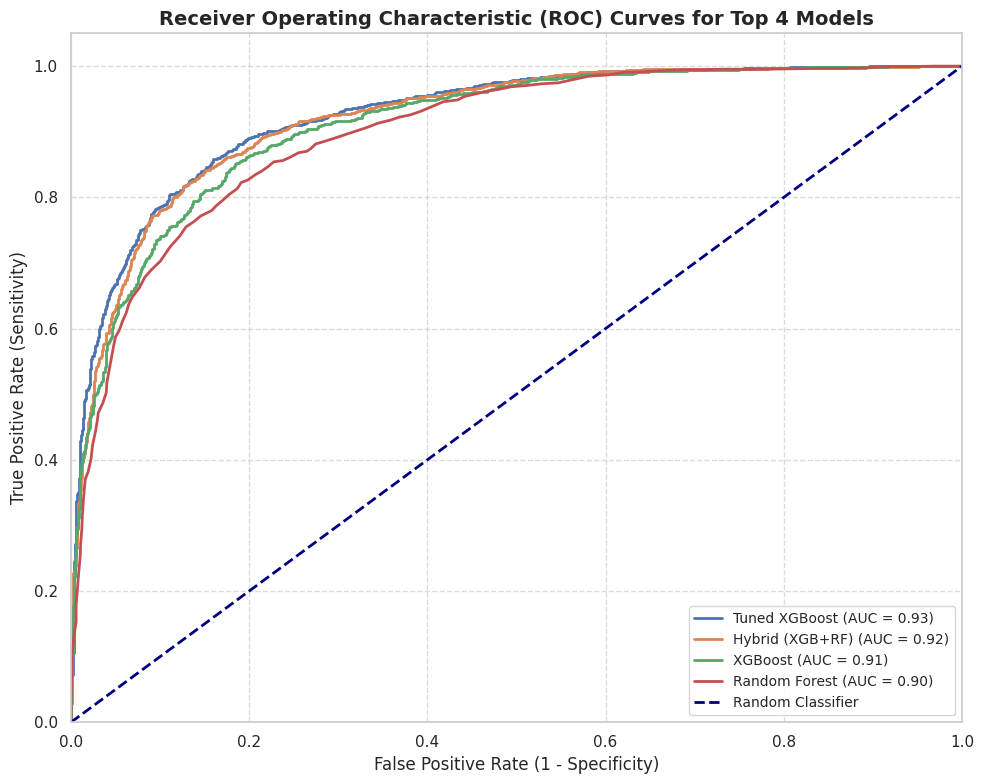

In [57]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Map model names to their respective trained objects
model_map = {
    'Tuned XGBoost': best_xgb_model,
    'Hybrid (XGB+RF)': voting_clf,
    'XGBoost': xgb_model,
    'Random Forest': model
}

plt.figure(figsize=(10, 8))
sns.set_theme(style='whitegrid')

# Iterate through the top 4 models and plot their ROC curves
for model_name in top_4_models_df['Model']:
    if model_name in model_map:
        current_model = model_map[model_name]

        # Get predicted probabilities for the positive class (Dropout = 1)
        # For SVC, we need to ensure `probability=True` was set during initialization,
        # but in this case, none of the top 4 are SVC, so predict_proba will work.
        y_scores = current_model.predict_proba(X_test_scaled)[:, 1]

        # Calculate ROC curve and AUC
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')
    else:
        print(f"Warning: Model '{model_name}' not found in model_map. Skipping ROC curve.")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves for Top 4 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()